# GraphDTA — Drug-Target Binding Affinity Prediction (with Cross-Attention)

_Notes and explanations below are mine._


## Step 1: Environment Setup


In [1]:
# Works on both Colab and Kaggle: we never cd into the repo, we just
# reference "GraphDTA/..." paths relative to wherever this notebook starts.
import torch
print("Torch version (before install):", torch.__version__)

# --no-deps avoids pip silently upgrading/downgrading the torch build that
# already matches this platform's GPU (this caused a CUDA kernel error before).
!pip install torch_geometric --no-deps -q
!pip install rdkit -q

import os, json, pickle, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from rdkit import Chem
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_add_pool

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch version (after install):", torch.__version__, "  <- should be unchanged")
print("Device:", device)

if device.type == "cuda":
    major, minor = torch.cuda.get_device_capability(0)
    if major < 7:
        print(f"⚠️ GPU compute capability {major}.{minor} is too old for this PyTorch build.")
        print("Go to Settings → Accelerator → switch to 'GPU T4 x2' instead of P100.")
        device = torch.device("cpu")
        print("Falling back to CPU for now.")
        
if not os.path.exists("GraphDTA"):
    !git clone -q https://github.com/thinng/GraphDTA.git

print("Davis files:", os.listdir("GraphDTA/data/davis"))
print("KIBA files:", os.listdir("GraphDTA/data/kiba"))


Torch version (before install): 2.10.0+cu128
Torch version (after install): 2.10.0+cu128   <- should be unchanged
Device: cuda
Davis files: ['ligands_can.txt', 'folds', 'Y', 'proteins.txt']
KIBA files: ['ligands_can.txt', 'folds', 'Y', 'proteins.txt']


## Step 2: SMILES → Graph (Drug Representation)


In [2]:
ATOM_LIST = [
    'C', 'N', 'O', 'S', 'F', 'Si', 'P', 'Cl', 'Br', 'Mg', 'Na', 'Ca',
    'Fe', 'As', 'Al', 'I', 'B', 'V', 'K', 'Tl', 'Yb', 'Sb', 'Sn', 'Ag',
    'Pd', 'Co', 'Se', 'Ti', 'Zn', 'H', 'Li', 'Ge', 'Cu', 'Au', 'Ni',
    'Cd', 'In', 'Mn', 'Zr', 'Cr', 'Pt', 'Hg', 'Pb', 'Unknown'
]

def one_hot_encoding(value, allowed_values):
    if value not in allowed_values:
        value = allowed_values[-1]
    return [1.0 if value == v else 0.0 for v in allowed_values]

def get_atom_features(atom):
    features = []
    features += one_hot_encoding(atom.GetSymbol(), ATOM_LIST)
    features += one_hot_encoding(atom.GetDegree(), list(range(11)))
    features += one_hot_encoding(atom.GetTotalNumHs(), list(range(11)))
    features += one_hot_encoding(atom.GetValence(Chem.ValenceType.IMPLICIT), list(range(11)))
    features += [1.0 if atom.GetIsAromatic() else 0.0]
    return features

def smiles_to_graph(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"RDKit couldn't parse SMILES: {smiles}")

    atom_features = [get_atom_features(a) for a in mol.GetAtoms()]
    x = torch.tensor(atom_features, dtype=torch.float)

    edges = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edges.append([i, j]); edges.append([j, i])
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    return Data(x=x, edge_index=edge_index)


In [3]:
# quick sanity check
aspirin = smiles_to_graph("CC(=O)Oc1ccccc1C(=O)O")
print("Aspirin -> atoms:", aspirin.num_nodes, "| feature dim:", aspirin.x.shape[1],
      "| directed edges:", aspirin.edge_index.shape[1])


Aspirin -> atoms: 13 | feature dim: 78 | directed edges: 26


## Step 3: Protein Sequence Encoding


In [4]:
SEQ_VOCAB = "ABCDEFGHIKLMNOPQRSTUVWXYZ"
SEQ_DICT = {v: (i + 1) for i, v in enumerate(SEQ_VOCAB)}   # 0 reserved for padding
MAX_SEQ_LEN = 1000

def encode_protein(sequence: str, max_len: int = MAX_SEQ_LEN) -> np.ndarray:
    encoding = np.zeros(max_len, dtype=np.int64)
    for i, ch in enumerate(sequence[:max_len]):
        encoding[i] = SEQ_DICT.get(ch, 0)
    return encoding


## Step 4: Building the Dataset (Drugs + Proteins + Affinity Labels)


In [5]:
def load_raw_data(dataset="davis"):
    data_dir = f"GraphDTA/data/{dataset}"
    with open(f"{data_dir}/ligands_can.txt") as f: drugs = json.load(f)
    with open(f"{data_dir}/proteins.txt") as f: proteins = json.load(f)
    with open(f"{data_dir}/Y", "rb") as f: Y = pickle.load(f, encoding="latin1")

    if dataset == "davis":
        Y = -np.log10(Y / 1e9)   # Kd (nM) -> pKd
    # KIBA scores are already on a usable scale, no conversion needed

    return drugs, proteins, Y


def build_pairs(Y, fold_indices):
    # Fold indices point into the list of VALID (non-NaN) entries, not the
    # raw flattened matrix. Doesn't matter for Davis (fully dense), but is
    # essential for KIBA (many missing drug-protein pairs).
    valid_rows, valid_cols = np.where(~np.isnan(Y))
    pairs = []
    for idx in fold_indices:
        row, col = valid_rows[idx], valid_cols[idx]
        pairs.append((row, col, Y[row, col]))
    return pairs


class DTADataset(InMemoryDataset):
    def __init__(self, pairs, drug_graphs, protein_encodings):
        super().__init__()
        data_list = []
        for row, col, affinity in pairs:
            graph = drug_graphs[row]
            protein_vec = protein_encodings[col]
            sample = Data(
                x=graph.x, edge_index=graph.edge_index,
                target=torch.tensor(np.array([protein_vec]), dtype=torch.long),
                y=torch.tensor([affinity], dtype=torch.float),
            )
            data_list.append(sample)
        self.data, self.slices = self.collate(data_list)


def build_datasets(dataset_name):
    drugs, proteins, Y = load_raw_data(dataset_name)
    drug_ids = list(drugs.keys())
    drug_graphs = {i: smiles_to_graph(drugs[d]) for i, d in enumerate(drug_ids)}
    protein_ids = list(proteins.keys())
    protein_encodings = {i: encode_protein(proteins[p]) for i, p in enumerate(protein_ids)}

    with open(f"GraphDTA/data/{dataset_name}/folds/train_fold_setting1.txt") as f:
        train_folds = json.load(f)
    with open(f"GraphDTA/data/{dataset_name}/folds/test_fold_setting1.txt") as f:
        test_fold = json.load(f)

    train_idx = [i for fold in train_folds for i in fold]
    train_pairs = build_pairs(Y, train_idx)
    test_pairs = build_pairs(Y, test_fold)

    train_ds = DTADataset(train_pairs, drug_graphs, protein_encodings)
    test_ds = DTADataset(test_pairs, drug_graphs, protein_encodings)
    print(f"{dataset_name}: train={len(train_ds)}  test={len(test_ds)}")
    return train_ds, test_ds


## Step 5: DataLoader & Batching


In [6]:
train_dataset, test_dataset = build_datasets("davis")

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

batch = next(iter(train_loader))
print("batch.x:", batch.x.shape)
print("batch.edge_index:", batch.edge_index.shape)
print("batch.target:", batch.target.shape)
print("batch.y:", batch.y.shape)
print("num_graphs in batch:", batch.num_graphs)


davis: train=25046  test=5010
batch.x: torch.Size([4168, 78])
batch.edge_index: torch.Size([2, 9230])
batch.target: torch.Size([128, 1000])
batch.y: torch.Size([128])
num_graphs in batch: 128


## Step 6–8: Model Architecture — GIN (drug) + CNN (protein) + Cross-Attention


In [7]:
class GINDrugEncoder(nn.Module):
    def __init__(self, input_dim=78, hidden_dim=32, output_dim=128, num_layers=5):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        for i in range(num_layers):
            in_dim = input_dim if i == 0 else hidden_dim
            mlp = nn.Sequential(nn.Linear(in_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
            self.convs.append(GINConv(mlp))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x, edge_index)))
        x = global_add_pool(x, batch)
        return F.relu(self.fc(x))


In [8]:
class CNNProteinEncoder(nn.Module):
    """
    Returns PER-RESIDUE features (no pooling here) so the attention layer
    below can decide which residues matter for each specific drug.
    padding='same' keeps the sequence length fixed at MAX_SEQ_LEN throughout,
    so attention position i always corresponds to residue i in the original sequence.
    """
    def __init__(self, vocab_size=26, embed_dim=128, num_filters=32, kernel_sizes=(4, 6, 8)):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k, padding='same') for k in kernel_sizes
        ])
        self.out_dim = num_filters * len(kernel_sizes)

    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1)              # [batch, embed_dim, seq_len]
        conv_outs = [F.relu(c(emb)) for c in self.convs]      # each: [batch, num_filters, seq_len]
        residue_features = torch.cat(conv_outs, dim=1)         # [batch, out_dim, seq_len]
        return residue_features.permute(0, 2, 1)                # [batch, seq_len, out_dim]


In [9]:
class DrugProteinAttention(nn.Module):
    """
    Cross-attention: the drug vector asks "which residues matter most to me?"
    query = drug vector | key/value = per-residue protein features
    """
    def __init__(self, drug_dim, protein_dim, attn_dim=128):
        super().__init__()
        self.query_proj = nn.Linear(drug_dim, attn_dim)
        self.key_proj = nn.Linear(protein_dim, attn_dim)
        self.value_proj = nn.Linear(protein_dim, protein_dim)

    def forward(self, drug_vec, residue_features, protein_seq):
        query = self.query_proj(drug_vec).unsqueeze(1)                    # [batch, 1, attn_dim]
        keys = self.key_proj(residue_features)                            # [batch, seq_len, attn_dim]
        values = self.value_proj(residue_features)                        # [batch, seq_len, protein_dim]

        scores = torch.bmm(query, keys.transpose(1, 2)) / (keys.size(-1) ** 0.5)  # [batch, 1, seq_len]

        # Mask out padding positions so attention never focuses on empty slots
        mask = (protein_seq == 0).unsqueeze(1)
        scores = scores.masked_fill(mask, float('-inf'))

        attn_weights = F.softmax(scores, dim=-1)               # [batch, 1, seq_len]
        pooled = torch.bmm(attn_weights, values).squeeze(1)    # [batch, protein_dim]

        return pooled, attn_weights.squeeze(1)   # also return weights, for interpretability


In [10]:
class GraphDTA(nn.Module):
    def __init__(self, drug_output_dim=128, protein_output_dim=128):
        super().__init__()
        self.drug_encoder = GINDrugEncoder(output_dim=drug_output_dim)
        self.protein_encoder = CNNProteinEncoder()
        self.attention = DrugProteinAttention(
            drug_dim=drug_output_dim,
            protein_dim=self.protein_encoder.out_dim,
        )
        self.protein_fc = nn.Linear(self.protein_encoder.out_dim, protein_output_dim)

        combined_dim = drug_output_dim + protein_output_dim
        self.fc1 = nn.Linear(combined_dim, 256)
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(256, 64)
        self.dropout2 = nn.Dropout(0.2)
        self.out = nn.Linear(64, 1)

    def forward(self, data, return_attention=False):
        drug_vec = self.drug_encoder(data.x, data.edge_index, data.batch)

        residue_features = self.protein_encoder(data.target)
        protein_vec, attn_weights = self.attention(drug_vec, residue_features, data.target)
        protein_vec = F.relu(self.protein_fc(protein_vec))

        combined = torch.cat([drug_vec, protein_vec], dim=1)
        x = F.relu(self.fc1(combined))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        prediction = self.out(x).squeeze(-1)

        if return_attention:
            return prediction, attn_weights   # attn_weights: [batch, seq_len]
        return prediction


In [11]:
# sanity check: forward pass + loss + backward pass all work
model = GraphDTA().to(device)
print("Total parameters:", sum(p.numel() for p in model.parameters()))

test_batch = batch.to(device)
output, attn = model(test_batch, return_attention=True)
loss = nn.MSELoss()(output, test_batch.y)
loss.backward()
print("Output shape:", output.shape, "| attention shape:", attn.shape, "| loss:", loss.item())


Total parameters: 226817


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(


Output shape: torch.Size([128]) | attention shape: torch.Size([128, 1000]) | loss: 28.003116607666016


## Step 9–10: Training Loop + Evaluation Metrics (MSE & Concordance Index)


In [12]:
def concordance_index(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    order = np.argsort(y_true)
    y_true, y_pred = y_true[order], y_pred[order]
    concordant, total = 0.0, 0.0
    for i in range(len(y_true)):
        for j in range(i):
            if y_true[i] != y_true[j]:
                total += 1
                if y_pred[i] > y_pred[j]: concordant += 1.0
                elif y_pred[i] == y_pred[j]: concordant += 0.5
    return concordant / total if total > 0 else 0.0


def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)
        loss = loss_fn(pred, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_true = 0.0, [], []
    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)
        loss = loss_fn(pred, batch.y)
        total_loss += loss.item() * batch.num_graphs
        all_preds.extend(pred.cpu().numpy())
        all_true.extend(batch.y.cpu().numpy())
    mse = total_loss / len(loader.dataset)
    ci = concordance_index(all_true, all_preds)
    return mse, ci, all_preds, all_true


## Step 11: Full Training Run — Early Stopping + Checkpointing


In [13]:
def run_full_training(dataset_name, max_epochs=1000, patience=20, batch_size=128,
                       lr=0.001, checkpoint_path=None, subset_size=None):
    if checkpoint_path is None:
        checkpoint_path = f"best_model_{dataset_name}.pt"

    train_ds, test_ds = build_datasets(dataset_name)
    if subset_size is not None:
        train_ds = train_ds[:subset_size]
        test_ds = test_ds[:max(subset_size // 5, 20)]

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")

    model = GraphDTA().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_mse, no_improve = float("inf"), 0
    history = []

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        test_mse, test_ci, _, _ = evaluate(model, test_loader, loss_fn, device)
        history.append({"epoch": epoch, "train_loss": train_loss, "test_mse": test_mse, "test_ci": test_ci})
        print(f"[{dataset_name}] Epoch {epoch:4d}: train_loss={train_loss:.4f}  "
              f"test_MSE={test_mse:.4f}  test_CI={test_ci:.4f}", end="")

        if test_mse < best_mse:
            best_mse, no_improve = test_mse, 0
            torch.save({"model_state_dict": model.state_dict(), "epoch": epoch, "best_mse": best_mse},
                       checkpoint_path)
            print("  <- saved")
        else:
            no_improve += 1
            print()

        if no_improve >= patience:
            print(f"No improvement for {patience} epochs. Stopping early at epoch {epoch}.")
            break

    print(f"\n=== {dataset_name.upper()} FINAL: best MSE = {best_mse:.4f} | checkpoint: {checkpoint_path} ===\n")
    return history, checkpoint_path


In [14]:
# Full run on Davis (remove subset_size or set to None for the full 25046/5010 split)
davis_history, davis_ckpt = run_full_training(
    "davis", max_epochs=1000, patience=20, batch_size=128, subset_size=None
)


davis: train=25046  test=5010
Train: 25046 | Test: 5010
[davis] Epoch    1: train_loss=1.5757  test_MSE=0.7352  test_CI=0.7251  <- saved
[davis] Epoch    2: train_loss=1.0057  test_MSE=0.6817  test_CI=0.7257  <- saved
[davis] Epoch    3: train_loss=0.9742  test_MSE=0.6044  test_CI=0.7667  <- saved
[davis] Epoch    4: train_loss=0.9279  test_MSE=0.6042  test_CI=0.7607  <- saved
[davis] Epoch    5: train_loss=0.9152  test_MSE=0.6731  test_CI=0.7322
[davis] Epoch    6: train_loss=0.8954  test_MSE=0.5860  test_CI=0.7599  <- saved
[davis] Epoch    7: train_loss=0.8554  test_MSE=0.5658  test_CI=0.7773  <- saved
[davis] Epoch    8: train_loss=0.8424  test_MSE=0.5648  test_CI=0.7591  <- saved
[davis] Epoch    9: train_loss=0.8341  test_MSE=0.6349  test_CI=0.7710
[davis] Epoch   10: train_loss=0.8246  test_MSE=0.6191  test_CI=0.7681
[davis] Epoch   11: train_loss=0.8077  test_MSE=0.6263  test_CI=0.7913
[davis] Epoch   12: train_loss=0.7882  test_MSE=0.5331  test_CI=0.7870  <- saved
[davis] Epoc

In [15]:
# Full run on KIBA (separate checkpoint file so it doesn't overwrite Davis's)
kiba_history, kiba_ckpt = run_full_training(
    "kiba", max_epochs=1000, patience=20, batch_size=256, subset_size=None
)


kiba: train=98545  test=19709
Train: 98545 | Test: 19709
[kiba] Epoch    1: train_loss=4.1213  test_MSE=0.5436  test_CI=0.6798  <- saved
[kiba] Epoch    2: train_loss=1.8252  test_MSE=0.5165  test_CI=0.6983  <- saved
[kiba] Epoch    3: train_loss=1.7316  test_MSE=0.5017  test_CI=0.7010  <- saved
[kiba] Epoch    4: train_loss=1.7270  test_MSE=0.4800  test_CI=0.7062  <- saved
[kiba] Epoch    5: train_loss=1.6611  test_MSE=0.4773  test_CI=0.7127  <- saved
[kiba] Epoch    6: train_loss=1.6654  test_MSE=0.5207  test_CI=0.7200
[kiba] Epoch    7: train_loss=1.5883  test_MSE=0.4650  test_CI=0.7147  <- saved
[kiba] Epoch    8: train_loss=1.5653  test_MSE=0.4607  test_CI=0.7196  <- saved
[kiba] Epoch    9: train_loss=1.4971  test_MSE=0.4320  test_CI=0.7260  <- saved
[kiba] Epoch   10: train_loss=1.4841  test_MSE=0.5027  test_CI=0.7198
[kiba] Epoch   11: train_loss=1.4363  test_MSE=0.4385  test_CI=0.7287
[kiba] Epoch   12: train_loss=1.3778  test_MSE=0.4900  test_CI=0.7037
[kiba] Epoch   13: trai

## Step 12: Final Test Evaluation


In [27]:
def final_test_evaluation(dataset_name, checkpoint_path):
    _, test_ds = build_datasets(dataset_name)
    test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

    model = GraphDTA().to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded {dataset_name} model from epoch {checkpoint['epoch']}")

    loss_fn = nn.MSELoss()
    mse, ci, preds, true_vals = evaluate(model, test_loader, loss_fn, device)

    print(f"\n{dataset_name.upper()} — Final Test Results:  MSE={mse:.4f}  CI={ci:.4f}")
    return {"mse": mse, "ci": ci, "preds": preds, "true": true_vals, "model": model}


davis_results = final_test_evaluation("davis", davis_ckpt)
kiba_results = final_test_evaluation("kiba", kiba_ckpt)


davis: train=25046  test=5010
Loaded davis model from epoch 124

DAVIS — Final Test Results:  MSE=0.2847  CI=0.8721
kiba: train=98545  test=19709
Loaded kiba model from epoch 121

KIBA — Final Test Results:  MSE=0.2217  CI=0.8341


## Step 13: Visualize Predictions


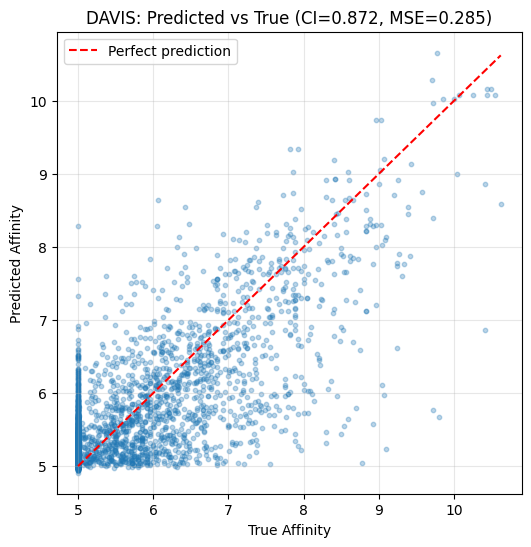

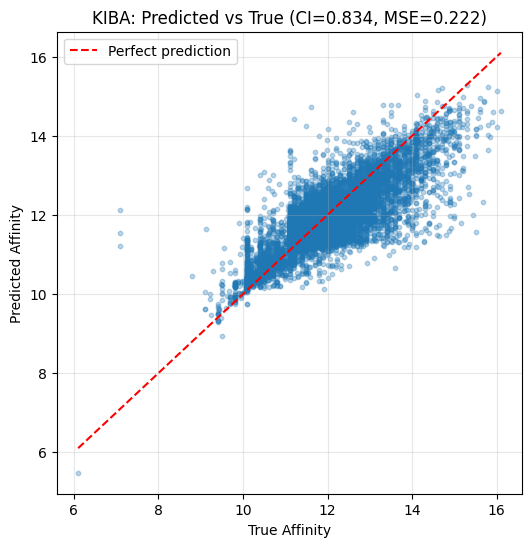

In [28]:
import matplotlib.pyplot as plt

def plot_predictions(results, dataset_name):
    plt.figure(figsize=(6, 6))
    plt.scatter(results["true"], results["preds"], alpha=0.3, s=10)
    lims = [min(results["true"]), max(results["true"])]
    plt.plot(lims, lims, 'r--', label="Perfect prediction")
    plt.xlabel("True Affinity")
    plt.ylabel("Predicted Affinity")
    plt.title(f"{dataset_name.upper()}: Predicted vs True (CI={results['ci']:.3f}, MSE={results['mse']:.3f})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_predictions(davis_results, "davis")
plot_predictions(kiba_results, "kiba")


## Step 14: Compare to Paper Results


In [29]:
import pandas as pd

comparison = {
    "Davis": {
        "Your GIN+Attention": {"CI": davis_results["ci"], "MSE": davis_results["mse"]},
        "Paper GIN":          {"CI": 0.882, "MSE": 0.147},
        "Paper GAT_GCN":      {"CI": 0.891, "MSE": 0.139},
        "DeepDTA (paper)":    {"CI": 0.878, "MSE": 0.261},
    },
    "KIBA": {
        "Your GIN+Attention": {"CI": kiba_results["ci"], "MSE": kiba_results["mse"]},
        "Paper GIN":          {"CI": 0.840, "MSE": 0.147},
    },
}

for dataset_name, models in comparison.items():
    print(f"\n{'='*40}\n{dataset_name}\n{'='*40}")
    print(pd.DataFrame(models).T)



Davis
                          CI       MSE
Your GIN+Attention  0.872091  0.284742
Paper GIN           0.882000  0.147000
Paper GAT_GCN       0.891000  0.139000
DeepDTA (paper)     0.878000  0.261000

KIBA
                          CI       MSE
Your GIN+Attention  0.834072  0.221658
Paper GIN           0.840000  0.147000


## Step 15: Extract Top Interacting Residues (Attention Interpretability)


In [30]:
@torch.no_grad()
def get_top_interacting_residues(model, batch, top_k=10):
    """
    For each drug-protein pair in the batch, returns the residue positions
    the model "focused on" most when predicting the affinity.
    NOTE: positions are 0-indexed into the padded/truncated sequence
    (see encode_protein, MAX_SEQ_LEN=1000) -- map back to the original
    protein sequence string if you need the actual residue identity.
    """
    model.eval()
    batch = batch.to(device)
    predictions, attn_weights = model(batch, return_attention=True)

    results = []
    for i in range(batch.num_graphs):
        weights = attn_weights[i].cpu().numpy()
        top_positions = weights.argsort()[::-1][:top_k]
        results.append({
            "predicted_affinity": predictions[i].item(),
            "top_residue_positions": top_positions.tolist(),
            "attention_scores": weights[top_positions].tolist(),
        })
    return results


# Example: inspect the first batch of the Davis test set
example_batch = next(iter(DataLoader(test_dataset, batch_size=8, shuffle=False)))
interactions = get_top_interacting_residues(davis_results["model"], example_batch, top_k=10)

for i, r in enumerate(interactions):
    print(f"Pair {i}: predicted={r['predicted_affinity']:.2f}")
    print(f"  Top residue positions: {r['top_residue_positions']}")
    print(f"  Attention scores:      {[round(s, 3) for s in r['attention_scores']]}")


Pair 0: predicted=5.59
  Top residue positions: [164, 343, 342, 341, 340, 339, 338, 337, 336, 335]
  Attention scores:      [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Pair 1: predicted=5.07
  Top residue positions: [352, 342, 341, 340, 339, 338, 337, 336, 335, 334]
  Attention scores:      [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Pair 2: predicted=5.14
  Top residue positions: [164, 343, 342, 341, 340, 339, 338, 337, 336, 335]
  Attention scores:      [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Pair 3: predicted=8.73
  Top residue positions: [775, 342, 341, 340, 339, 338, 337, 336, 335, 334]
  Attention scores:      [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Pair 4: predicted=5.28
  Top residue positions: [569, 342, 341, 340, 339, 338, 337, 336, 335, 334]
  Attention scores:      [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Pair 5: predicted=5.71
  Top residue positions: [151, 343, 342, 341, 340, 339, 338, 337, 336, 335]
  Attention scores:      [

In [26]:
import os
from kaggle_secrets import UserSecretsClient
from huggingface_hub import HfApi, create_repo

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")   # نفس القيمة اللي إنت جبتها، بس بالاسم اللي الكود التاني بيستخدمه

# تأكيد سريع إن الـ token اتقرا صح من غير ما نكشفه كامل
print("Token loaded, starts with:", hf_token[:5])

assert os.path.exists("best_model_davis.pt"), "Davis checkpoint مش موجود!"
assert os.path.exists("best_model_kiba.pt"), "KIBA checkpoint مش موجود لسه!"

repo_id = "Abdulrhman2002/graphdta-checkpoints"

api = HfApi(token=hf_token)
create_repo(repo_id, token=hf_token, exist_ok=True, repo_type="model")

api.upload_file(path_or_fileobj="best_model_davis.pt",
                 path_in_repo="best_model_davis.pt", repo_id=repo_id)
api.upload_file(path_or_fileobj="best_model_kiba.pt",
                 path_in_repo="best_model_kiba.pt", repo_id=repo_id)

print(f"✅ اتحفظوا على: https://huggingface.co/{repo_id}")

Token loaded, starts with: hf_nb


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


✅ اتحفظوا على: https://huggingface.co/Abdulrhman2002/graphdta-checkpoints
